# 🫁 Lung Cancer Detection using ResNet50

This notebook fine-tunes a pretrained **ResNet50** model on a CT scan dataset to detect lung cancer.  
Dataset used: **CT Scan Images for Lung Cancer** from Kaggle.  
The model is built using **TensorFlow/Keras** and outputs binary predictions: **Cancer** or **No Cancer**.

We use:
- `ImageDataGenerator` for data augmentation
- `ResNet50` as the backbone CNN
- Binary Crossentropy loss for training

Model will be exported as `.h5` for deployment on Hugging Face.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report


2025-06-08 06:39:31.304436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749364771.486689      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749364771.541198      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import pandas as pd
from pathlib import Path

# Define dataset path
DATASET_PATH = '/kaggle/input/ct-scan-images-for-lung-cancer/LungcancerDataSet/Data'

def build_dataframe(base_dir):
    classes = {'Cancer': 1, 'No_Cancer': 0}
    data = []

    for label_folder in os.listdir(base_dir):
        full_path = os.path.join(base_dir, label_folder)

        if not os.path.isdir(full_path):
            continue

        label = None
        if 'normal' in label_folder.lower() or 'benign' in label_folder.lower():
            label = classes['No_Cancer']
        else:
            label = classes['Cancer']

        for file in Path(full_path).rglob("*.png"):
            data.append((str(file), label))

    return pd.DataFrame(data, columns=["filename", "label"])

# Build all splits
train_df = build_dataframe(os.path.join(DATASET_PATH, 'train'))
valid_df = build_dataframe(os.path.join(DATASET_PATH, 'valid'))
test_df  = build_dataframe(os.path.join(DATASET_PATH, 'test'))

train_df['label'] = train_df['label'].astype(str)
valid_df['label'] = valid_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

train_df.head()

,filename,label
0,/kaggle/input/ct-scan-images-for-lung-cancer/L...,1
1,/kaggle/input/ct-scan-images-for-lung-cancer/L...,1
2,/kaggle/input/ct-scan-images-for-lung-cancer/L...,1
3,/kaggle/input/ct-scan-images-for-lung-cancer/L...,1
4,/kaggle/input/ct-scan-images-for-lung-cancer/L...,1


## Load Dataset

The dataset is already organized in train/valid/test folders.
We'll use Keras `ImageDataGenerator` for loading and preprocessing the images.


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

valid_gen = datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

Found 602 validated image filenames belonging to 2 classes.
Found 72 validated image filenames belonging to 2 classes.


## Build the ResNet50 Model

We load ResNet50 with `imagenet` weights and `include_top=False`.  
Then, we add our own classification head and freeze the base model for initial training.


In [4]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze for initial training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


I0000 00:00:1749364787.804514      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749364787.805206      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Train the Model

We now train the model using the training and validation datasets.


In [5]:
EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1749364801.287455      61 service.cc:148] XLA service 0x7c790004f150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749364801.288099      61 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749364801.288122      61 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749364802.811592      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/19 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.4531 - loss: 0.7546 

I0000 00:00:1749364807.619577      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 936ms/step - accuracy: 0.7102 - loss: 0.6356 - val_accuracy: 0.8889 - val_loss: 0.2558
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.8673 - loss: 0.3032 - val_accuracy: 0.9583 - val_loss: 0.1396
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.9023 - loss: 0.2031 - val_accuracy: 0.9583 - val_loss: 0.1230
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.9330 - loss: 0.1701 - val_accuracy: 0.9583 - val_loss: 0.1127
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.9386 - loss: 0.1467 - val_accuracy: 0.9583 - val_loss: 0.1198
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.9468 - loss: 0.1367 - val_accuracy: 0.9583 - val_loss: 0.1029
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.9546 - loss: 0.1303 - val_accuracy: 0.9583 - val_loss: 0.1149
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.9289 - loss: 0.1529 - val_accuracy: 0.9583 - val

## Evaluate and Visualize Performance

We'll now plot training curves and show a confusion matrix on the validation set.


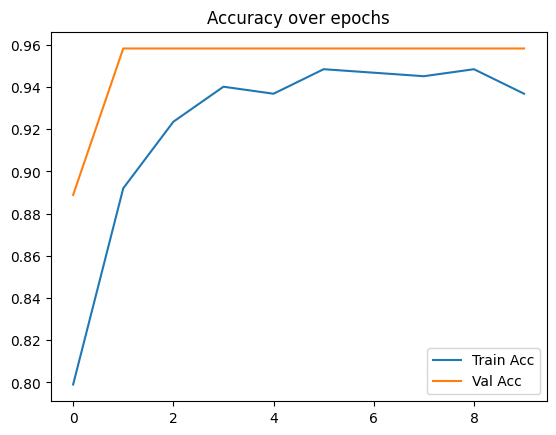

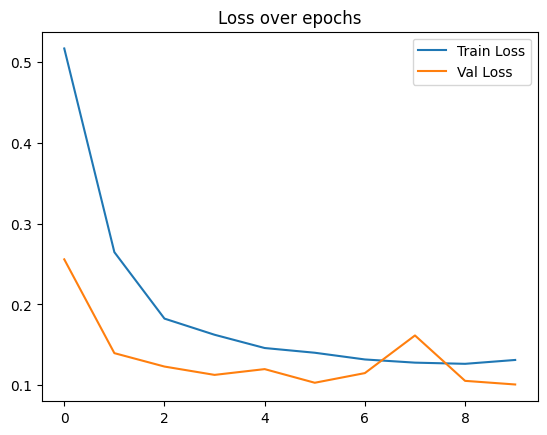

Found 72 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
[[10  3]
 [ 0 59]]
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.95      1.00      0.98        59

    accuracy                           0.96        72
   macro avg       0.98      0.88      0.92        72
weighted avg       0.96      0.96      0.96        72



In [6]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss over epochs')
plt.show()

# Predict on validation set for confusion matrix
val_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

preds = model.predict(val_generator)
y_pred = (preds > 0.5).astype("int32")
y_true = val_generator.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

## 💾 Save the Model

We now export the trained model as `.h5` for deployment to Hugging Face.


In [7]:
model.save("resnet50_lung_model.h5")
print("Model saved!")


Model saved!
